СЛУЧАЙНЫЙ ЛЕС
OOB Score: 0.8930
Test Accuracy: 0.8934

ADABOOST
Test Accuracy: 0.8493

GRADIENT BOOSTING
Test Accuracy: 0.8878



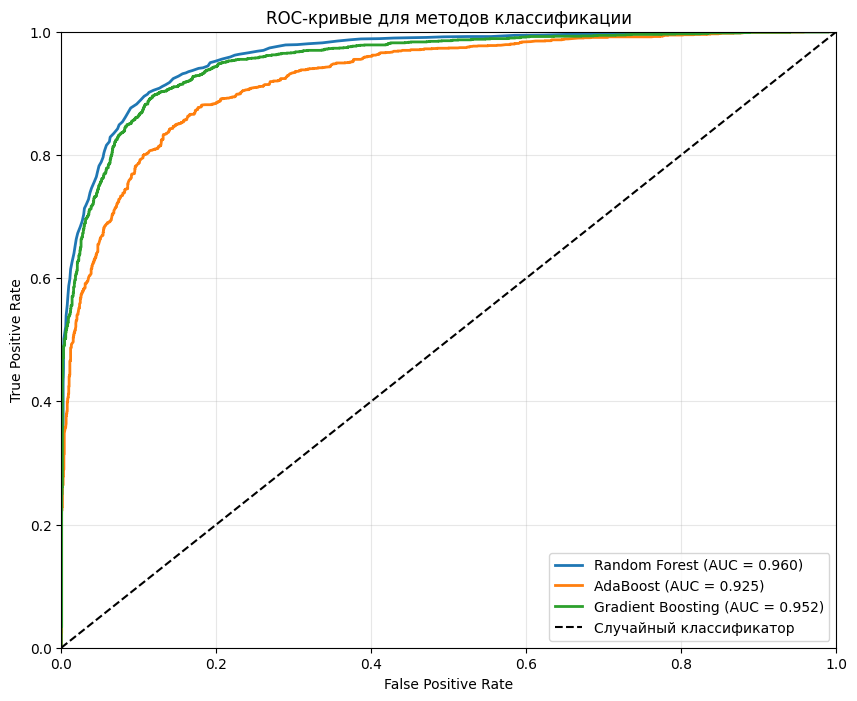

ROC-кривые сохранены в файл 'roc_curves.png'


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_curve, auc, accuracy_score

housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = (housing.target > np.median(housing.target)).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("СЛУЧАЙНЫЙ ЛЕС")
rf = RandomForestClassifier(n_estimators=100, max_features='sqrt', oob_score=True, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

print(f"OOB Score: {rf.oob_score_:.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, rf.predict(X_test)):.4f}\n")

print("ADABOOST")
ada = AdaBoostClassifier(n_estimators=100, learning_rate=1.0, random_state=42)
ada.fit(X_train, y_train)
print(f"Test Accuracy: {accuracy_score(y_test, ada.predict(X_test)):.4f}\n")

print("GRADIENT BOOSTING")
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train, y_train)
print(f"Test Accuracy: {accuracy_score(y_test, gb.predict(X_test)):.4f}\n")

models = {'Random Forest': rf, 'AdaBoost': ada, 'Gradient Boosting': gb}

plt.figure(figsize=(10, 8))

for name, model in models.items():
    y_score = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые для методов классификации')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("ROC-кривые сохранены в файл 'roc_curves.png'")